In [2]:
import os
import pandas as pd

In [3]:
INPUT = "C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\inmet 250126"

In [4]:
df = pd.read_csv(os.path.join(INPUT, os.listdir(INPUT)[1]), sep = ";", skiprows = 10).drop(columns = ["Unnamed: 2"])

In [5]:
df['Data Medicao'] = pd.to_datetime(df['Data Medicao'], format = '%Y-%m-%d').dt.date
df['Ano'] = pd.to_datetime(df['Data Medicao'], format = '%Y-%m-%d').dt.year

In [6]:
na_years = df.groupby('Ano')['PRECIPITACAO TOTAL, DIARIO(mm)'].apply(lambda x: x.isna().sum())

In [7]:
df = df[~df['Ano'].isin(na_years[na_years > 74].index)]

Generalizing:

In [21]:
INPUT = "C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\inmet 250126"
OUTPUT = "C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\TSLab input"

for i in range(len(os.listdir(INPUT))):
    df = pd.read_csv(os.path.join(INPUT, os.listdir(INPUT)[i]), sep = ";", skiprows = 10).drop(columns = ["Unnamed: 2"])
    df['Data Medicao'] = pd.to_datetime(df['Data Medicao'], format = '%Y-%m-%d').dt.date
    df['Ano'] = pd.to_datetime(df['Data Medicao'], format = '%Y-%m-%d').dt.year
    na_years = df.groupby('Ano')['PRECIPITACAO TOTAL, DIARIO(mm)'].apply(lambda x: x.isna().sum())
    df_rem_na = df[~df['Ano'].isin(na_years[na_years > 74].index)]
    df_train = df_rem_na.tail(3650 + 730).head(3650)
    df_train['PRECIPITACAO TOTAL, DIARIO(mm)'] = df_train['PRECIPITACAO TOTAL, DIARIO(mm)'].str.replace(",", ".").astype(float).values
    df_test = df.iloc[df_rem_na.tail(3650 + 730).head(3650).index[-1]:].tail(-1)
    df_test['PRECIPITACAO TOTAL, DIARIO(mm)'] = df_test['PRECIPITACAO TOTAL, DIARIO(mm)'].str.replace(",", ".").astype(float).values
    df_train.to_csv(os.path.join(OUTPUT, os.listdir(INPUT)[i].split(".")[0] + "_train.csv"), sep = ",", index = False)
    df_test.to_csv(os.path.join(OUTPUT, os.listdir(INPUT)[i].split(".")[0] + "_test.csv"), sep = ",", index = False)

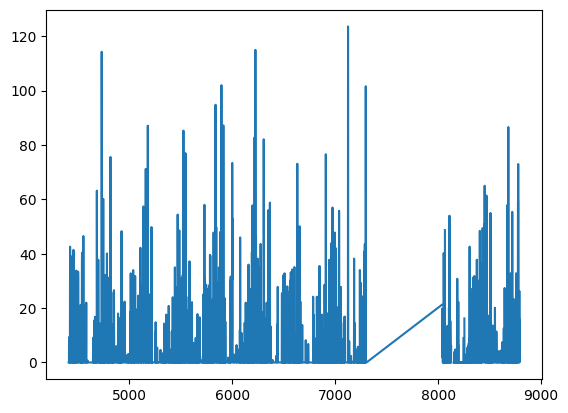

In [23]:
import matplotlib.pyplot as plt
plt.plot(df_train['PRECIPITACAO TOTAL, DIARIO(mm)'])

In [15]:
import matplotlib.pyplot as plt

In [25]:
df_train['PRECIPITACAO TOTAL, DIARIO(mm)'].str.replace(",", ".").astype(float).values

array([46. ,  5.9,  0. , ...,  0. ,  0. ,  0.8], shape=(3650,))

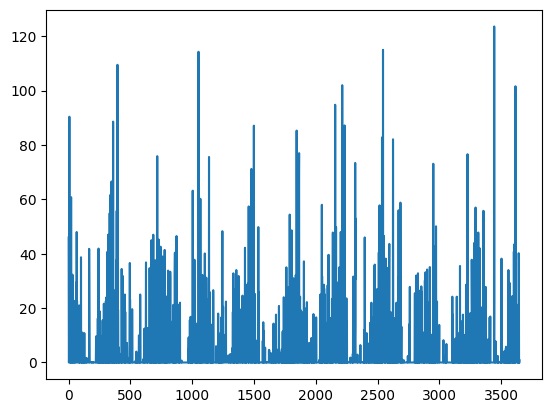

In [26]:
plt.plot(df_train['PRECIPITACAO TOTAL, DIARIO(mm)'].str.replace(",", ".").astype(float).values)